dummy-spatialdata is compatible with both spatialdata == 0.5.0 (zarr v2) and 0.7.2 (zarr v3)

Thus please use 
1. conda create --name dummy_sd_env python==3.12 spatialdata==0.7.2
or 
2. conda create --name dummy_sd_env_05 python==3.12 spatialdata==0.5.0 setuptools==75.8.0

In [1]:
from dummy_spatialdata import generate_dataset
import dummy_anndata
import spatialdata_plot as sdp 
import spatialdata as sd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad
import tempfile as tf

/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# generate anndata
adata = dummy_anndata.generate_dataset(n_obs=12, n_vars=20)
adata2 = dummy_anndata.generate_dataset(n_obs=20, n_vars=20)

# generate spatialdata
sdata = generate_dataset(
    images = [
        {'type': 'rgb', 'scale_factors': [2,2,2], 'coordinate_system': 'global'},
        {'type': 'grayscale', 'coordinate_system': 'global'},
    ],
    labels = [
        {'n': 12, 'scale_factors': [2,2,3], 'coordinate_system': 'global2'},
        {'n': 12, 'coordinate_system': 'global2'},
    ], 
    shapes = [
        {'n': 12, 'type': 'circle', 'coordinate_system': 'global'},
        {'n': 20, 'type': 'polygon'},
    ],
    points = [
        {'n': 12}
    ],
    tables = [
        {'table': adata, 'element': 'shape', 'element_index': 0},
        {'table': adata2, 'element': 'shape', 'element_index': 1}
    ],
    coordinate_systems = {
        'global': {'transformations': ['affine'], 'shape': {'x': 2000, 'y': 2000}},
        'global2': {'transformations': ['scale', 'translation'], 'shape':{'x': 500, 'y': 500}}
    },
    SEED=13
)
sdata

/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.12/site-packages/spatialdata/models/models.py:1206: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)
/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.12/site-packages/spatialdata/models/models.py:1206: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)


SpatialData object
├── Images
│     ├── 'image_0': DataTree[cyx] (3, 2000, 2000), (3, 1000, 1000), (3, 500, 500), (3, 250, 250)
│     └── 'image_1': DataTree[cyx] (1, 2000, 2000)
├── Labels
│     ├── 'label_0': DataTree[yx] (500, 500), (250, 250), (125, 125), (41, 41)
│     └── 'label_1': DataTree[yx] (500, 500)
├── Points
│     └── 'point_0': DataFrame with shape: (<Delayed>, 2) (2D points)
├── Shapes
│     ├── 'shape_0': GeoDataFrame shape: (12, 2) (2D shapes)
│     └── 'shape_1': GeoDataFrame shape: (20, 1) (2D shapes)
└── Tables
      ├── 'table_0': AnnData (12, 20)
      └── 'table_1': AnnData (20, 20)
with coordinate systems:
    ▸ 'global', with elements:
        image_0 (Images), image_1 (Images), shape_0 (Shapes)
    ▸ 'global2', with elements:
        label_0 (Labels), label_1 (Labels)
    ▸ 'point_0', with elements:
        point_0 (Points)
    ▸ 'shape_1', with elements:
        shape_1 (Shapes)

In [3]:
sdata = generate_dataset(
    points = [
        {'n': 12}
    ],
    SEED=13
)

{}


In [3]:
# write to temp
filename = tf.NamedTemporaryFile()
filename.name + ".zarr"
sdata.write(filename.name + ".zarr")

# read back
sdata = sd.read_zarr(filename.name + ".zarr")

/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.12/site-packages/ome_zarr/writer.py:319: FutureWarning: Passing storage-related arguments via **kwargs is deprecated. Please use the 'zarr_store_kwargs' parameter instead. **kwargs will be removed in a future version.
  da_delayed = da.to_zarr(


/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'shape_1', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/Users/amanuky/miniforge3/envs/dummy_sd_env/lib/python3.12/site-packages/spatialdata/_core/operations/transform.py:501: UserWarning: The vector part of the transformation matrix is not isotropic, the radius will be scaled by the average of the modules of eigenvalues of the affine transformation matrix.
matrix=[[0.5 0.2 0. ]
 [0.1 0.5 0. ]
 [0.  0.  1. ]]
eigenvalues=[0.64142136 0.35857864]
scale_factor=0.5
  new_radii = scale_radii(radii=old_radii, affine=affine, axes=axes)


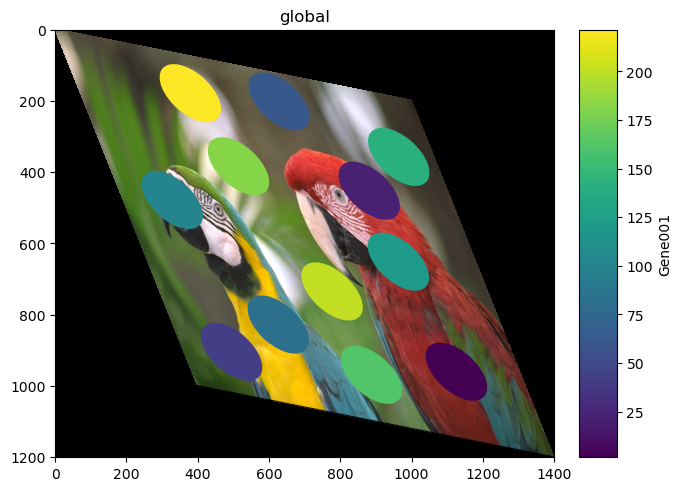

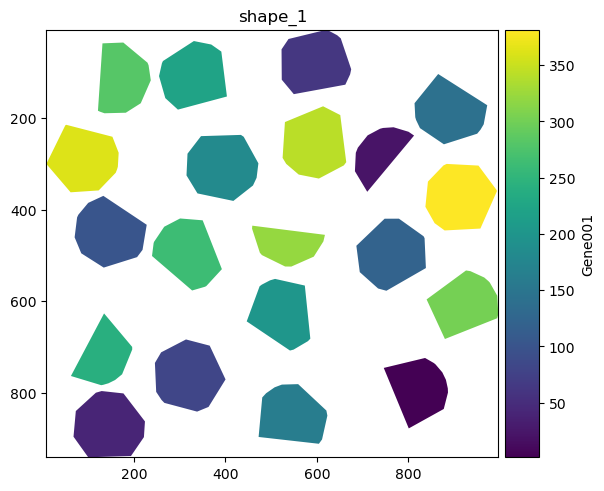

In [12]:
sdata.pl.render_images("image_0").pl.render_shapes("shape_0", color="Gene001", table_name = "table_0", table_layer = "float_matrix").pl.show(coordinate_systems = "global")
sdata.pl.render_shapes("shape_1", color="Gene001", table_name = "table_1", table_layer = "float_matrix").pl.show(coordinate_systems = "shape_1")